<p align="center">
  <img src="./yibo-quant.jpg" alt="课程封面" width="1300"/>
</p>


# 《和Yibo零基础学习量化金融》
## 从Python到AI量化交易实战 第一期
### 第三章：移动平均线策略

---

## 本章你将学会

- ✅ 区分 **上涨趋势、下跌趋势、噪声**（配图）
- ✅ 理解为什么要用 **移动平均** 看整体走势
- ✅ 计算 **MA5 / MA20**，认出 **金叉 / 死叉**
- ✅ 写出第一个规则：`if MA5 > MA20: 持有`
- ✅ 在图上标 **买点、卖点** 和持仓状态

**当前等级**  
🎮 **Lv.2 策略设计师**

**本章难度**  
⭐⭐☆☆☆

**预计学习时间**  
30～45 分钟（后半段需联网）

**前置知识**

- 完成 **第二章**（收益率、`pct_change`）
- Python 基础、会用 Jupyter

---

从这一章开始，我们真正进入 **「策略」** —— 很多读者最期待的部分：**把看盘直觉写成 if 规则**。

### 环境准备

In [1]:
# ========== 环境准备 ==========
import warnings
warnings.filterwarnings('ignore')  # 隐藏无关警告

import numpy as np              # 数值计算
import pandas as pd             # 表格数据
import matplotlib.pyplot as plt   # 画图
import yfinance as yf           # 下载股票行情（需联网）

plt.rcParams['font.sans-serif'] = ['SimHei']   # 图表中文
plt.rcParams['axes.unicode_minus'] = False    # 负号正常

TICKER = 'AAPL'   # 股票代码，可改成 TSLA、NVDA
PERIOD = '2y'     # 下载多长历史（均线需要足够天数）

print('环境就绪 ✓')


环境就绪 ✓


---

### 3.1 什么是趋势？

打开行情软件，最常听到三个词：

| 说法 | 直觉含义 |
|------|----------|
| **上涨趋势** | 价格整体在往上走，低点越来越高 |
| **下跌趋势** | 价格整体在往下走，高点越来越低 |
| **噪声** | 短期上蹿下跳，像「毛刺」，不一定代表大方向变了 |

量化策略的第一步，就是先把 **大方向（趋势）** 和 **每日乱动（噪声）** 分开。

下面用一段 **模拟价格** 把三种状态画在一起（真实股票也是这三种的混合）。

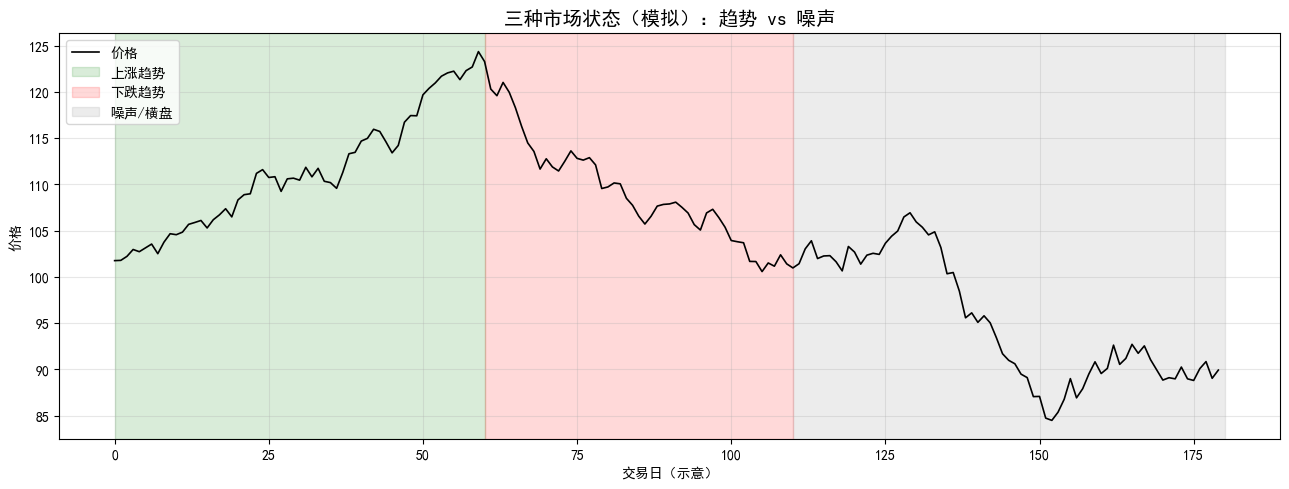

绿色区：整体向上 | 红色区：整体向下 | 灰色区：方向不明显、抖动大


In [2]:
# ========== 模拟三种市场状态并分区上色 ==========
np.random.seed(7)              # 固定随机数，图可复现
n_up, n_down, n_noise = 60, 50, 70  # 上涨段、下跌段、横盘段各多少天

ret_up = np.random.normal(0.004, 0.008, n_up)        # 上涨段：平均日收益偏正
ret_down = np.random.normal(-0.005, 0.010, n_down)   # 下跌段：平均日收益偏负
ret_noise = np.random.normal(0.0, 0.015, n_noise)    # 横盘：均值约0，波动大

price = 100 * np.cumprod(1 + np.r_[ret_up, ret_down, ret_noise])  # 拼成价格
x = np.arange(len(price))  # 横轴：第几个交易日

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(x, price, color='black', linewidth=1.2, label='价格')

ax.axvspan(0, n_up, alpha=0.15, color='green', label='上涨趋势')
ax.axvspan(n_up, n_up + n_down, alpha=0.15, color='red', label='下跌趋势')
ax.axvspan(n_up + n_down, len(price), alpha=0.15, color='gray', label='噪声/横盘')

ax.set_title('三种市场状态（模拟）：趋势 vs 噪声', fontsize=14)
ax.set_xlabel('交易日（示意）')
ax.set_ylabel('价格')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('绿色区：整体向上 | 红色区：整体向下 | 灰色区：方向不明显、抖动大')


---

### 3.2 为什么需要「平均」？

真实股票 **每天波动太乱**：一条消息、一笔大单，都可能让当天收盘价上蹿下跳。

但我们做策略时，更关心：

> **「整体趋势」到底在往上还是往下？**

解决办法很朴素：**把最近几天的价格取平均**，就像把毛刺磨平，留下更平滑的「趋势线」。

这就是 **移动平均线（Moving Average, MA）** 的直觉来源。

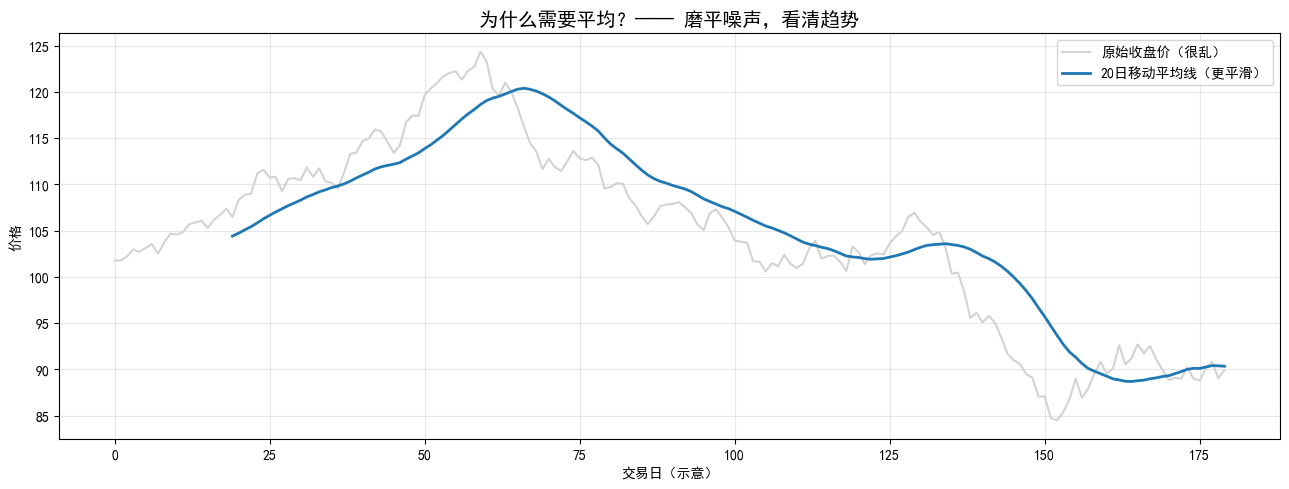

In [3]:
# ========== 对比「乱的价格」和「平滑的均线」==========
demo = pd.DataFrame({'Close': price})           # 用上面模拟的价格
demo['MA20'] = demo['Close'].rolling(20).mean()  # 20日移动平均

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(demo['Close'], label='原始收盘价（很乱）', color='lightgray', linewidth=1.5)
ax.plot(demo['MA20'], label='20日移动平均线（更平滑）', color='tab:blue', linewidth=2)
ax.set_title('为什么需要平均？—— 磨平噪声，看清趋势', fontsize=14)
ax.set_xlabel('交易日（示意）')
ax.set_ylabel('价格')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

### 3.3 移动平均线（核心）

**n 日简单移动平均线** 的定义：最近 n 天收盘价的算术平均。

$$
MA_n(t) = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}
$$

例如 **MA5** = 最近 5 天收盘价的平均；**MA20** = 最近 20 天收盘价的平均。

- n 越小 → 均线跟价格跟得越紧（更敏感）
- n 越大 → 均线越平滑（更迟钝，但更稳）

在 pandas 里，一行代码：

```python
df['MA5'] = df['Close'].rolling(5).mean()
```

In [4]:
# ========== 下载真实股票并计算 MA5、MA20 ==========
raw = yf.download(TICKER, period=PERIOD, progress=False, multi_level_index=False)  # 下载行情
df = raw[['Close']].dropna().copy()   # 只留收盘价，去掉空行
df.columns = ['Close']                # 列名统一成 Close

df['MA5'] = df['Close'].rolling(5).mean()    # 5日均线 = 最近5天收盘均价
df['MA20'] = df['Close'].rolling(20).mean()  # 20日均线

print(f'{TICKER} 共 {len(df)} 个交易日')
display(df.tail(8))  # 显示最后8行，检查算得对不对


AAPL 共 501 个交易日


,Close,MA5,MA20
Date,,,
2026-05-19,298.970001,298.823999,284.259996
2026-05-20,302.250000,299.500000,285.726567
2026-05-21,304.989990,300.856000,287.317151
2026-05-22,308.820007,302.573999,289.217627
2026-05-26,308.329987,304.671997,291.265944
2026-05-27,310.850006,307.047998,293.285403
2026-05-28,312.510010,309.100000,295.414838
2026-05-29,312.059998,310.514001,297.462825


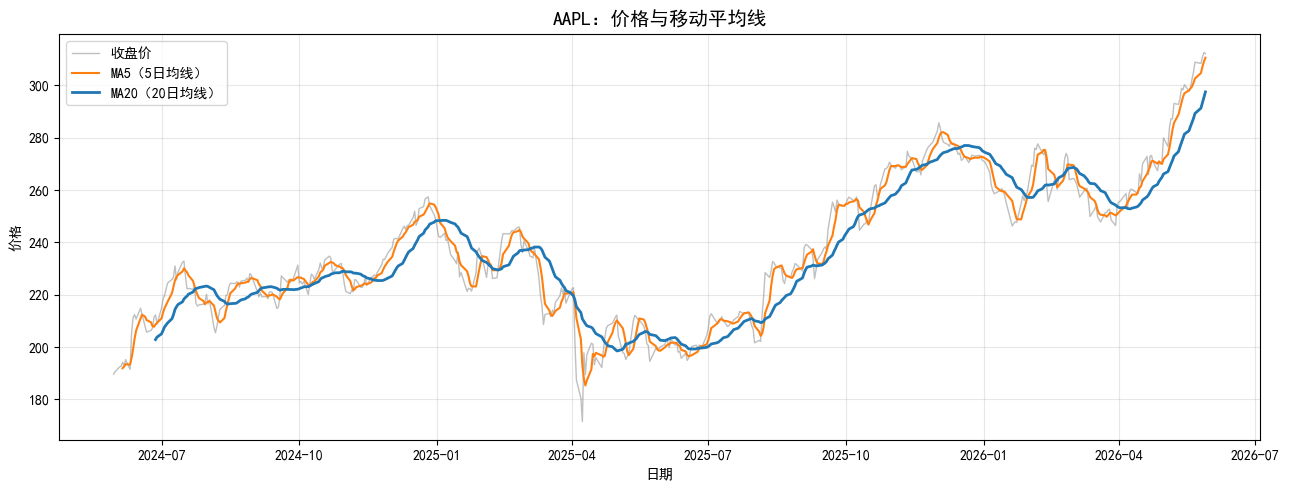

In [5]:
# ========== 画收盘价 + 两条均线 ==========
plt.figure(figsize=(13, 5))
plt.plot(df.index, df['Close'], label='收盘价', color='gray', alpha=0.5, linewidth=1)
plt.plot(df.index, df['MA5'], label='MA5（5日均线）', color='tab:orange', linewidth=1.5)
plt.plot(df.index, df['MA20'], label='MA20（20日均线）', color='tab:blue', linewidth=2)
plt.title(f'{TICKER}：价格与移动平均线', fontsize=14)
plt.xlabel('日期')
plt.ylabel('价格')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

### 3.4 5日均线 vs 20日均线（本章高潮）

当 **短期均线** 和 **长期均线** 放在一起，会出现两种经典形态：

| 名称 | 发生了什么 | 市场直觉 |
|------|------------|----------|
| **金叉** | MA5 **从下往上** 穿过 MA20 | 短期变强，常被看作 **偏多 / 买入信号** |
| **死叉** | MA5 **从上往下** 穿过 MA20 | 短期变弱，常被看作 **偏空 / 卖出信号** |

> 注意：金叉/死叉是 **描述交叉现象** 的用语，不等于「一定赚钱」——后面章节会做回测验证。

下面在图上标出每一个金叉、死叉的位置。

In [6]:
# ========== 检测金叉、死叉 ==========
df['spread'] = df['MA5'] - df['MA20']              # 短均线减长均线
df['cross'] = np.sign(df['spread']).diff()         # 符号变化：正=金叉，负=死叉

golden = df[df['cross'] > 0].dropna(subset=['MA5', 'MA20'])  # 金叉那些天
death = df[df['cross'] < 0].dropna(subset=['MA5', 'MA20'])    # 死叉那些天

print(f'样本期内 金叉 {len(golden)} 次，死叉 {len(death)} 次')
print('\n最近 3 次金叉日期：')
print(golden.tail(3).index.strftime('%Y-%m-%d').tolist())
print('\n最近 3 次死叉日期：')
print(death.tail(3).index.strftime('%Y-%m-%d').tolist())


样本期内 金叉 15 次，死叉 15 次

最近 3 次金叉日期：
['2026-02-02', '2026-02-25', '2026-04-06']

最近 3 次死叉日期：
['2025-12-17', '2026-02-19', '2026-03-03']


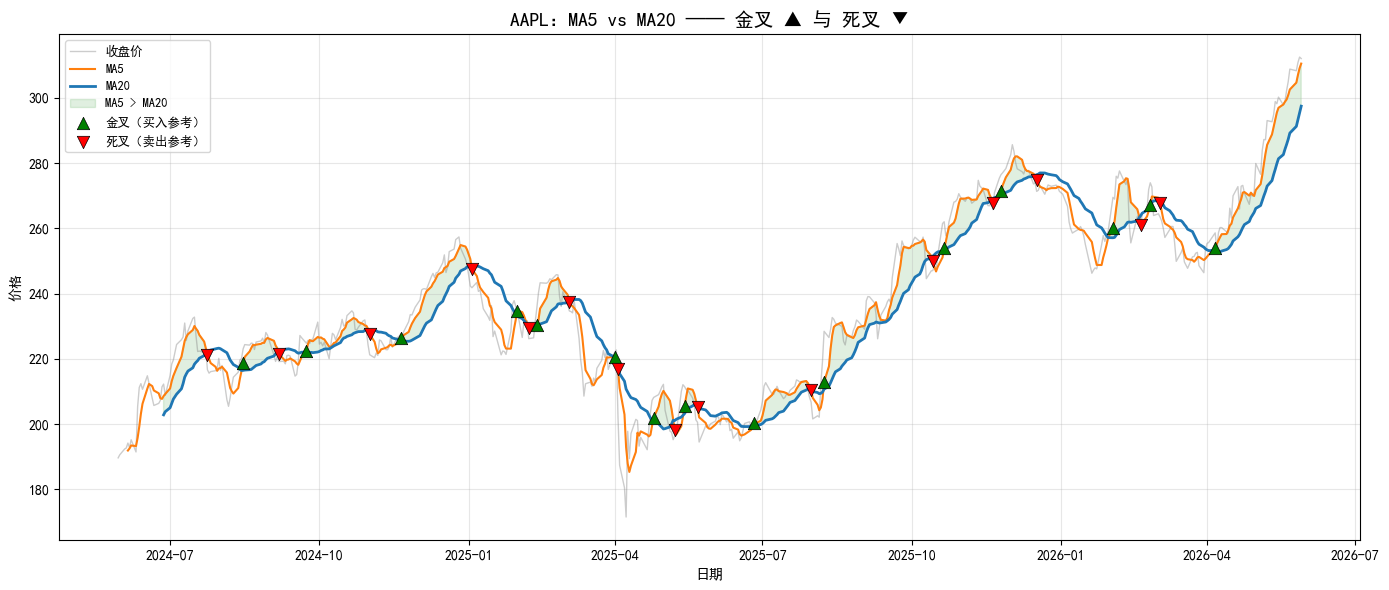

In [7]:
# ========== 金叉死叉标注图 ==========
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['Close'], color='gray', alpha=0.4, linewidth=1, label='收盘价')
ax.plot(df.index, df['MA5'], color='tab:orange', linewidth=1.5, label='MA5')
ax.plot(df.index, df['MA20'], color='tab:blue', linewidth=2, label='MA20')

ax.fill_between(df.index, df['MA5'], df['MA20'],
                where=(df['MA5'] >= df['MA20']),
                interpolate=True, alpha=0.12, color='green', label='MA5 > MA20')

ax.scatter(golden.index, golden['MA5'], marker='^', s=80, color='green',
           edgecolors='black', linewidths=0.5, zorder=5, label='金叉（买入参考）')
ax.scatter(death.index, death['MA5'], marker='v', s=80, color='red',
           edgecolors='black', linewidths=0.5, zorder=5, label='死叉（卖出参考）')

ax.set_title(f'{TICKER}：MA5 vs MA20 —— 金叉 ▲ 与 死叉 ▼', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('价格')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

### 3.5 你的第一个策略

把上面的直觉写成 **可执行的规则**（伪代码）：

```text
如果 MA5 > MA20:
    持有 / 买入
否则:
    空仓 / 卖出
```

这就是著名的 **双均线策略（Moving Average Crossover）** 的最简版本。

在 pandas 里，`signal = 1` 表示持仓，`0` 表示空仓：

In [8]:
# ========== 第一个策略：MA5>MA20 则持仓 ==========
df['signal'] = (df['MA5'] > df['MA20']).astype(int)  # 满足条件=1，否则=0

df['trade'] = 0                              # 默认无交易
df.loc[df['cross'] > 0, 'trade'] = 1         # 金叉日标记买入
df.loc[df['cross'] < 0, 'trade'] = -1        # 死叉日标记卖出

hold_days = df['signal'].sum()             # signal=1 的天数
print(f'规则：MA5 > MA20 则持仓 (signal=1)')
print(f'样本期内约 {hold_days} 个交易日处于持仓状态（共 {len(df)} 天）')
print(f'共产生 { (df["trade"] != 0).sum() } 次调仓信号（买+卖）')

display(df[df['trade'] != 0][['Close', 'MA5', 'MA20', 'signal', 'trade']].tail(6))


规则：MA5 > MA20 则持仓 (signal=1)
样本期内约 288 个交易日处于持仓状态（共 501 天）
共产生 30 次调仓信号（买+卖）


,Close,MA5,MA20,signal,trade
Date,,,,,
2025-12-17,271.335876,274.863324,276.447881,0,-1
2026-02-02,269.509308,260.012924,257.121791,1,1
2026-02-19,260.340118,261.023517,263.829490,0,-1
2026-02-25,273.977600,267.295734,267.226575,1,1
2026-03-03,263.507233,267.719348,268.343852,0,-1
2026-04-06,258.621704,253.932040,253.247176,1,1


**恭喜你** —— 你已经把「看盘感觉」写成了 **if 判断 + 表格列**，这就是量化策略的起点。

真实交易还要考虑手续费、滑点、能否当天成交等；**第四章回测** 会帮你用数据检验「这套规则到底赚没赚」。

小提示：为避免 **未来函数**，回测时常用 `signal.shift(1)`——今天收盘算出的信号，明天才能按它交易。本章先聚焦「规则与可视化」。

---

### 3.6 可视化策略信号（非常重要）

一张好的策略图应让人 **一眼看懂**：

- 价格 + 两条均线
- **绿色 ▲** = 买入点（金叉）
- **红色 ▼** = 卖出点（死叉）
- 下方色带 = 当前是持仓还是空仓

这类图会让你的 Notebook 立刻有「专业量化报告」的味道。

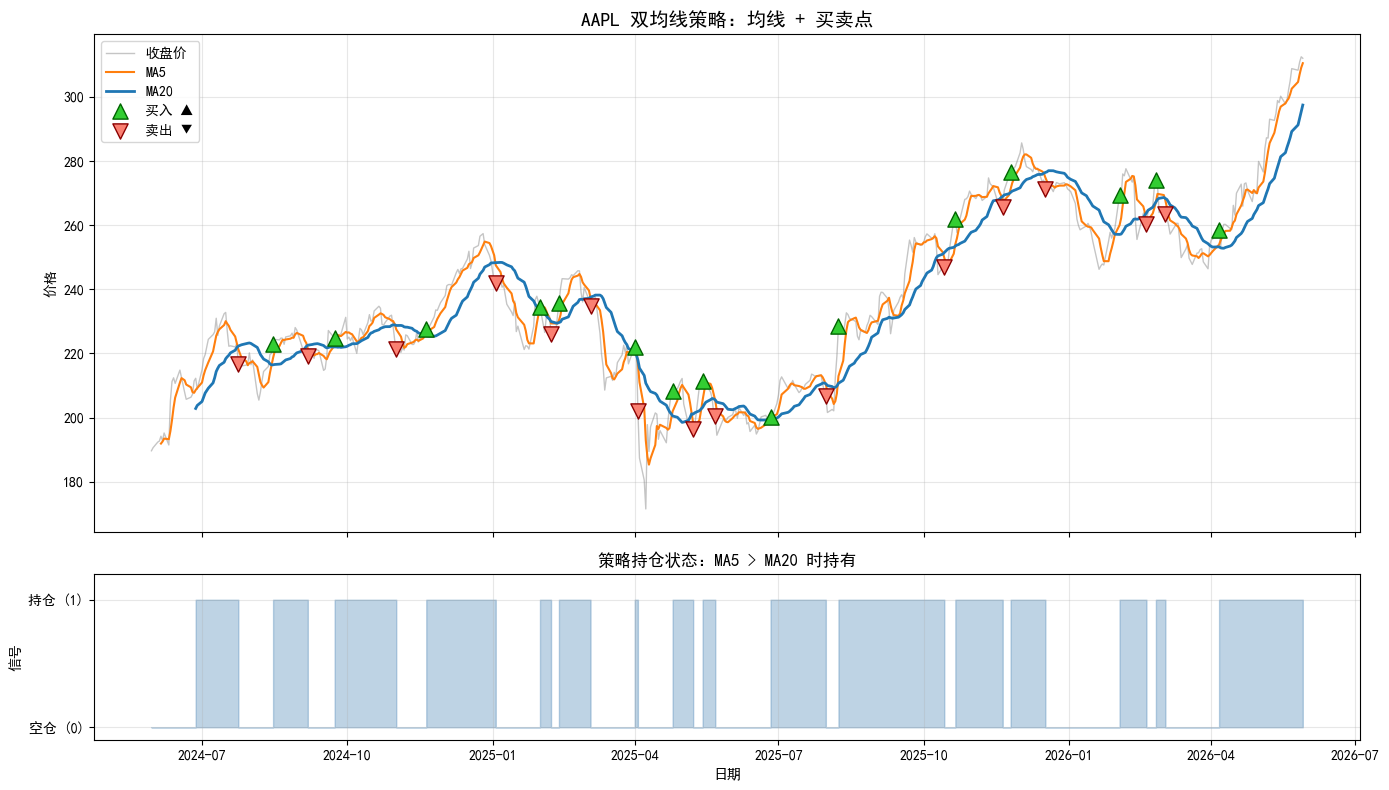

In [9]:
# ========== 策略信号大图：价格+买卖点+持仓条 ==========
buys = df[df['trade'] == 1]    # 所有买入日
sells = df[df['trade'] == -1]  # 所有卖出日

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})
ax_price, ax_pos = axes

ax_price.plot(df.index, df['Close'], color='gray', alpha=0.45, linewidth=1, label='收盘价')
ax_price.plot(df.index, df['MA5'], color='tab:orange', linewidth=1.5, label='MA5')
ax_price.plot(df.index, df['MA20'], color='tab:blue', linewidth=2, label='MA20')

ax_price.scatter(buys.index, buys['Close'], marker='^', s=120, color='limegreen',
                 edgecolors='darkgreen', linewidths=1, zorder=6, label='买入 ▲')
ax_price.scatter(sells.index, sells['Close'], marker='v', s=120, color='salmon',
                 edgecolors='darkred', linewidths=1, zorder=6, label='卖出 ▼')

ax_price.set_title(f'{TICKER} 双均线策略：均线 + 买卖点', fontsize=14)
ax_price.set_ylabel('价格')
ax_price.legend(loc='upper left')
ax_price.grid(True, alpha=0.3)

ax_pos.fill_between(df.index, 0, df['signal'], step='post', alpha=0.35, color='steelblue')
ax_pos.set_ylim(-0.1, 1.2)
ax_pos.set_yticks([0, 1])
ax_pos.set_yticklabels(['空仓 (0)', '持仓 (1)'])
ax_pos.set_xlabel('日期')
ax_pos.set_ylabel('信号')
ax_pos.set_title('策略持仓状态：MA5 > MA20 时持有', fontsize=12)
ax_pos.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


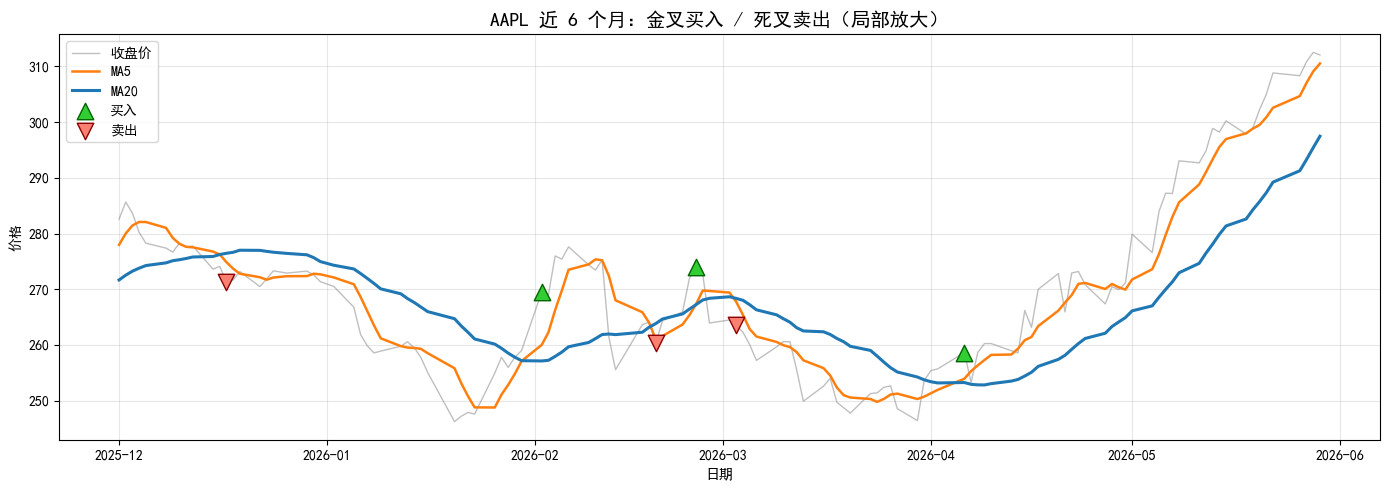

In [10]:
# ========== 放大最近6个月，看清买卖细节 ==========
recent = df.last('6M') if len(df) > 120 else df.tail(120)  # 取最近约6个月
buys_r = recent[recent['trade'] == 1]
sells_r = recent[recent['trade'] == -1]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(recent.index, recent['Close'], color='gray', alpha=0.5, linewidth=1, label='收盘价')
ax.plot(recent.index, recent['MA5'], color='tab:orange', linewidth=1.8, label='MA5')
ax.plot(recent.index, recent['MA20'], color='tab:blue', linewidth=2.2, label='MA20')
ax.scatter(buys_r.index, buys_r['Close'], marker='^', s=140, color='limegreen',
           edgecolors='darkgreen', linewidths=1, zorder=6, label='买入')
ax.scatter(sells_r.index, sells_r['Close'], marker='v', s=140, color='salmon',
           edgecolors='darkred', linewidths=1, zorder=6, label='卖出')
ax.set_title(f'{TICKER} 近 6 个月：金叉买入 / 死叉卖出（局部放大）', fontsize=14)
ax.set_xlabel('日期')
ax.set_ylabel('价格')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---

## 🎯 挑战任务（第三章通关）

1. 把 `TICKER` 改成 **`'TSLA'`**，截一张带 **金叉▲ / 死叉▼** 的图——这就是你的第一张「策略信号图」。  
2. 试试 **MA10 vs MA30**，和 MA5/MA20 比：买卖次数变多了还是变少了？  
3. **思考题**：金叉一定赚钱吗？为什么第四章要做回测？

---

## 本章总结

- **趋势** 是大方向；**噪声** 是短期乱动；均线用来「磨平」噪声。  
- $MA_n$ = 最近 n 天收盘价的平均；`rolling(n).mean()` 即可计算。  
- **金叉**（MA5 上穿 MA20）≈ 买入参考；**死叉** ≈ 卖出参考。  
- 你的第一个策略：`signal = (MA5 > MA20)` —— 你已经写出 **交易系统** 了。  
- 策略图 = 均线 + 买卖点 + 持仓色带，专业感来自 **可视化**。

**下一章预告**：第四章 **策略回测** —— 用历史数据回答：这套双均线规则，到底赚没赚钱？最大回撤有多大？